# S&P 500 Equity + Option Analytics: Feature Engineering

The strategy reads a signal off a name's listed options and holds the share, so the matrix
built here has to carry both sides of that trade: what the option market charges for a name's
coming month, and what the share has actually been doing. This notebook builds those families,
states the window and the delay each one carries, shows that withholding later dates leaves
every value unchanged, and writes the matrix stage 04 and stage 05 read.

## Learning objectives

- Build implied-volatility level, dynamics, skew and variance-premium families from a daily
  surface summary, beside the equity momentum they have to earn their place against
- Lag an input that is published late, and count the lag in sessions rather than in the rows
  the input happens to have
- State each family's lookback and information lag before writing the code that computes it,
  and assert the warmup that follows from it
- Show that withholding later dates leaves every feature value unchanged, which is what
  separates a trailing statistic from one fitted over the whole sample
- Read a matrix before modelling it: scale, cross-sectional spread, redundancy and decay

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.1-8.6. Reads the daily share bars and the daily option-surface summary
through `load_sp500_daily_bars()` and `load_sp500_options_surface()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and `config/setup.yaml`,
which declares the register, every window, the ranked columns and the holdout boundary. Writes
`features/financial.parquet` with a `.digest.json` sidecar, read by
[`04_model_based_features`](04_model_based_features.ipynb), which adds GARCH and regime features
on top of it, and by [`05_evaluation`](05_evaluation.ipynb), which tests fold by fold whether
any of it predicts. No screen for predictive content runs here: `05_evaluation` owns it and runs
it fold-aware.

In [1]:
"""S&P 500 Equity + Option Analytics: Feature Engineering."""

import warnings
from datetime import date

import numpy as np
import polars as pl
import yaml

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    assert_values_agree,
    assign_families,
    families_from_config,
    family_coverage,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    warmup_audit,
)
from data import load_sp500_daily_bars, load_sp500_options_surface
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "sp500_equity_option_analytics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
FEATURES_DIR = CASE_DIR / "features"

Both parameters bound the sample and both are read below. The share bars and the surface
summary are licensed extracts covering these five years, so the defaults span the data.
Trimming either end shortens a run at the cost of a shorter history for the trailing windows
in Section C, and every cross-sectional rank is taken within a date across whatever names are
quoted on it, so a trimmed run computes a different quantity rather than a smaller one.

In [2]:
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"

## Configuration

The register, every window, the ranked-column mapping, the surface selection and the holdout
boundary are declared in `config/setup.yaml` and bound here. A window retyped into a cell is a
second source of truth for a decision the register, the warmup assertion and the timing figure
all have to agree on, and the two copies drift apart the first time either is edited.

The decision cadence is what the persistence figure is measured against: a feature has to hold
its ordering for at least one rebalance to be tradable at that cadence, and this strategy
rebalances weekly on the primary label's horizon.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FEATURES = setup["features"]
FAMILIES = families_from_config(setup)
W = FEATURES["windows"]
RANKED = FEATURES["ranked"]
SURFACE = FEATURES["surface"]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
IV_LAG = int(setup["decision"]["iv_feature_lag"].split("_")[0])

# The panel key, the entity every trailing window is bounded by, and the partition every
# cross-sectional statistic is taken over.
PANEL_KEY = ["symbol", "timestamp"]
SECURITY = "sec_id"
WITHIN_DATE = "timestamp"

print(
    f"{len(FAMILIES)} declared families, {len(RANKED)} ranked columns, IV lagged {IV_LAG} session"
)
print(f"Holdout starts {HOLDOUT_START}; Section D rebuilds the matrix without it")
print(f"Surface buckets {SURFACE['dte_buckets']} at deltas {SURFACE['delta_targets']}")

8 declared families, 8 ranked columns, IV lagged 1 session
Holdout starts 2021-01-01; Section D rebuilds the matrix without it
Surface buckets {'7d': [5, 10], '30d': [25, 35], '90d': [80, 110]} at deltas {'atm': 0.5, '25d': 0.25, '10d': 0.1}


## A. What the thesis says should carry information

The hypothesis is cross-sectional and it is about a disagreement between two markets. The
option market prices a distribution of outcomes for a name over the coming month; the share
price says what the equity market pays for it today. The claim is that names whose options are
priced richly against what their shares go on to do can be ranked against each other, and that
the ranking pays over the following week.

The **carrier** is the level of implied volatility and what it is priced against. Around it sit
the shape of the surface, how the level moves, and the spread between what is implied and what
the share has realized, which is the quantity the hypothesis names directly.

The **conditioning** is realized volatility, which is a state variable rather than a signal:
it describes the dispersion a ranking has to be earned against and is not expected to rank
names on its own. Equity momentum is in the matrix for a different reason. It is the signal an
option-derived feature would have to replace, so carrying it is what makes a later comparison
mean anything.

The **frame** is the single decision date for every cross-sectional statistic and the security
for every trailing one. A level of implied volatility is not comparable between a utility and a
semiconductor, so eight of the columns are carried again as their percentile within the date.

The register is declared in `config/setup.yaml`, one row per family, and it is split by
**observability**: everything read off the option surface carries a one-session lag and
everything read off the share price does not, for the reason Section B gives.

In [4]:
register_frame(FAMILIES).select(
    ["family", "role", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,inputs,lookback (bars),lag (bars),frame
str,str,str,i64,i64,str
"""cross-sectional rank""","""signal""","""the eight level and dynamics c…",252,1,"""cross section within the decis…"
"""implied volatility level""","""signal""","""daily IV surface summary, delt…",1,1,"""time series"""
"""implied volatility dynamics""","""signal""","""at-the-money 30-day implied vo…",252,1,"""time series"""
"""skew and term structure""","""signal""","""25-delta put and call IV, and …",63,1,"""term structure"""
"""variance risk premium""","""signal""","""at-the-money implied volatilit…",63,1,"""time series"""
"""realized volatility""","""state""","""split- and dividend-adjusted O…",63,0,"""time series"""
"""equity momentum""","""signal""","""split- and dividend-adjusted c…",252,0,"""time series"""
"""surface quality""","""state""","""bid-ask spread and solver conv…",1,1,"""time series"""


## B. Inputs and their observability

Each row is one security and one session. Two frames arrive and they are not observable on the
same schedule.

The **share bars** arrive as printed prices beside `adj_factor`, the cumulative factor that puts
a price on a comparable footing with the rest of that security's history. A return taken on the
printed close is not a return: a four-for-one split reads as a three-quarter loss. Multiplying
gives the series every window below is taken over. A close is final at the close, so a statistic
of the closes through session $t$ is knowable at $t$ and carries no lag.

The entity every trailing window is bounded by is the **security**, `sec_id`, not the ticker. A
ticker is reassigned after a merger or a spin-off and `adj_factor` restarts with the new security,
so a window that steps across the change reads a price from one company against a price from
another. `02_labels` counts the changeovers in this extract and builds its labels the same way,
which is what makes a feature and the label it is scored against the same kind of quantity.

The **surface summary** reduces the option chain to one row per name and session, selecting the
contract closest to each delta target inside each fixed maturity bucket. Those buckets and
targets are declared in `config/setup.yaml` and printed above; the selection itself runs in
`data/equities/market/sp500/materialize_options.py`, upstream of this notebook.

**The surface is not knowable at the session it is dated.** End-of-day implied volatility is
solved and published after the close, so every surface column is shifted by the session
`setup.yaml::decision.iv_feature_lag` declares before anything is computed from it. The
dynamics in C.1 are then built on the lagged series rather than lagged after the fact, so a
z-score never mixes a lagged level with an unlagged history.

**The lag is counted in sessions, which is why the surface is reindexed before anything reads
it.** A name is not quoted on every session, so a shift over the surface's own rows would reach
back to whenever that name was last quoted and hand the model a fortnight-old level under the
name of yesterday's. Joining the surface onto the sessions the security traded makes the missing
ones visible as nulls, and every window after it - the lag, the fill, the momentum, the z-scores
and the trailing percentile - then counts sessions and means what the register says it means. The
forward fill carries a level over at most the number of sessions `features.windows.iv_forward_fill`
declares, which is a stated tolerance for a thin quote rather than a claim that the level is
current.

In [5]:
daily = (
    load_sp500_daily_bars(start_date=START_DATE, end_date=END_DATE)
    .with_columns((pl.col("close") * pl.col("adj_factor")).alias("adj_close"))
    .sort([SECURITY, "timestamp"])
)
surface_raw = load_sp500_options_surface(start_date=START_DATE, end_date=END_DATE)
SURFACE_COLS = [c for c in surface_raw.columns if c not in PANEL_KEY]

print(f"{daily.height:,} name-sessions of share bars, {daily['symbol'].n_unique()} tickers")
print(f"{daily[SECURITY].n_unique()} securities behind those tickers")
print(f"{surface_raw.height:,} surface rows carrying {len(SURFACE_COLS)} columns")
print(f"{daily['timestamp'].min()} to {daily['timestamp'].max()}")

635,703 name-sessions of share bars, 638 tickers
629 securities behind those tickers
530,503 surface rows carrying 13 columns
2017-01-03 to 2021-12-31


In [6]:
def on_session_grid(bars: pl.DataFrame, surface: pl.DataFrame) -> pl.DataFrame:
    """The surface, reindexed onto the sessions each security actually traded."""
    grid = bars.select(["symbol", SECURITY, "timestamp"])
    return grid.join(surface, on=PANEL_KEY, how="left").sort([SECURITY, "timestamp"])


def lag_surface(surface: pl.DataFrame) -> pl.DataFrame:
    """Shift every surface column by the declared lag, then carry it over a thin quote."""
    lagged = surface.with_columns(
        pl.col(c).shift(IV_LAG).over(SECURITY).alias(c) for c in SURFACE_COLS
    )
    return lagged.with_columns(
        pl.col(c).forward_fill(limit=W["iv_forward_fill"]).over(SECURITY).alias(c)
        for c in SURFACE_COLS
    )

## C. Feature construction, one subsection per family

### C.1 Implied volatility level, dynamics, skew and term structure

The level columns arrive from the surface summary and need no construction. What is built here
is how the level sits against its own recent history: the session-over-session change, the
change over the two momentum windows, the rolling z-scores, and where the level stands inside
its own trailing range. Every one of them is a trailing statistic of one security's own series,
and every window comes from `features.windows`.

A z-score divides by a trailing standard deviation, which approaches zero for a name whose
implied volatility barely moves. The denominator is floored so that a near-constant series
returns a bounded number rather than an unbounded one, and the floor is a fixed constant rather
than a quantity fitted to the sample.

In [7]:
ZERO_FLOOR = 0.001


def _zscore(column: str, window: int) -> pl.Expr:
    """Trailing z-score of *column* over *window* sessions within one security."""
    mean = pl.col(column).rolling_mean(window).over(SECURITY)
    std = pl.col(column).rolling_std(window).over(SECURITY).clip(lower_bound=ZERO_FLOOR)
    return (pl.col(column) - mean) / std


def surface_dynamics(surface: pl.DataFrame) -> pl.DataFrame:
    """Changes, momentum, z-scores and the trailing percentile of the lagged surface."""
    pct_window = W["iv_percentile"]
    low = pl.col("iv_30_atm").rolling_min(pct_window).over(SECURITY)
    high = pl.col("iv_30_atm").rolling_max(pct_window).over(SECURITY)
    return surface.with_columns(
        *[
            (pl.col(c) - pl.col(c).shift(1).over(SECURITY)).alias(f"d_{c}")
            for c in ("iv_30_atm", "skew_rr_30_25d", "term_ratio_atm")
        ],
        *[
            (pl.col("iv_30_atm") - pl.col("iv_30_atm").shift(w).over(SECURITY)).alias(
                f"iv_mom_{w}d"
            )
            for w in W["iv_momentum"]
        ],
        *[_zscore("iv_30_atm", w).alias(f"iv_30_atm_z_{w}") for w in W["iv_zscore"]],
        _zscore("skew_rr_30_25d", W["skew_zscore"]).alias(f"skew_rr_z_{W['skew_zscore']}"),
        _zscore("term_ratio_atm", W["term_zscore"]).alias(f"term_ratio_z_{W['term_zscore']}"),
        ((pl.col("iv_30_atm") - low) / (high - low).clip(lower_bound=ZERO_FLOOR)).alias(
            f"iv_30_atm_pct_{pct_window}"
        ),
    )

### C.2 Realized volatility

What the share actually did, on four estimators that disagree in ways worth carrying. All of them
read the adjusted close inside one security, for the reason Section B gives. The close-to-close
standard deviation is the plain one and is computed at two windows. Garman-Klass
reads the whole daily range, so it sees an intraday move that opened and closed in the same
place; its per-session term can go negative on a bar whose open and close straddle the range,
so the average is floored at zero before the square root rather than after it. The volatility
of volatility is the dispersion of the short estimator itself, and the realized skew is the
third moment of standardized returns, which says whether the dispersion came from moves in one
direction.

In [8]:
ANNUALIZE = setup["evaluation"]["periods_per_year"] ** 0.5
GK_COEFFICIENT = 2 * np.log(2) - 1


def realized_volatility(bars: pl.DataFrame) -> pl.DataFrame:
    """Close-to-close, range-based and higher-moment volatility from the share bars."""
    short, long_ = W["realized_vol"]
    gk_window, vv_window, skew_window = W["garman_klass"], W["vol_of_vol"], W["realized_skew"]
    df = bars.with_columns(
        pl.col("adj_close").pct_change().over(SECURITY).alias("_ret")
    ).with_columns(
        (
            0.5 * (pl.col("high") / pl.col("low")).log().pow(2)
            - GK_COEFFICIENT * (pl.col("close") / pl.col("open")).log().pow(2)
        ).alias("_gk_session")
    )
    df = df.with_columns(
        *[
            (pl.col("_ret").rolling_std(w).over(SECURITY) * ANNUALIZE).alias(f"rv_{w}")
            for w in (short, long_)
        ],
        (
            pl.col("_gk_session").rolling_mean(gk_window).over(SECURITY).clip(lower_bound=0.0)
            * setup["evaluation"]["periods_per_year"]
        )
        .sqrt()
        .alias(f"gk_vol_{gk_window}"),
    )
    standardized = pl.col("_ret") / pl.col("_ret").rolling_std(skew_window).over(SECURITY).clip(
        lower_bound=ZERO_FLOOR / 10
    )
    return df.with_columns(
        pl.col(f"rv_{short}")
        .rolling_std(vv_window)
        .over(SECURITY)
        .alias(f"vol_of_vol_{vv_window}"),
        standardized.pow(3)
        .rolling_mean(skew_window)
        .over(SECURITY)
        .alias(f"realized_skew_{skew_window}"),
    ).select(
        [
            *PANEL_KEY,
            f"rv_{short}",
            f"rv_{long_}",
            f"gk_vol_{gk_window}",
            f"vol_of_vol_{vv_window}",
            f"realized_skew_{skew_window}",
        ]
    )

### C.3 Equity momentum

The simple return at five horizons, its skip-month form, and its volatility-scaled twin, all on
the adjusted close within one security. Skip-
month momentum runs from the start window to the recent window and divides prices rather than
subtracting returns, because returns compound and the difference of two window returns is not
the return over the gap between them (Jegadeesh and Titman, 1993). The risk-adjusted form
divides the medium-horizon return by the annualized volatility realized over the same span,
with the denominator floored at the level `features.windows.risk_adjusted_vol_floor` declares
so that a name that barely moved does not return an unbounded ratio.

In [9]:
PRICE_FLOOR = 1e-8


def equity_momentum(bars: pl.DataFrame) -> pl.DataFrame:
    """Multi-horizon returns, skip-month momentum and its volatility-scaled form."""
    ra_window = W["risk_adjusted"]
    df = bars.select([*PANEL_KEY, SECURITY, "adj_close"]).with_columns(
        pl.col("adj_close").pct_change().over(SECURITY).alias("_ret")
    )
    df = df.with_columns(
        *[
            (
                pl.col("adj_close")
                / pl.col("adj_close").shift(w).over(SECURITY).clip(lower_bound=PRICE_FLOOR)
                - 1
            ).alias(f"mom_{w}d")
            for w in W["momentum"]
        ],
        (
            pl.col("adj_close").shift(W["skip_recent"]).over(SECURITY)
            / pl.col("adj_close")
            .shift(W["skip_start"])
            .over(SECURITY)
            .clip(lower_bound=PRICE_FLOOR)
            - 1
        ).alias("mom_skip_recent"),
        (pl.col("_ret").rolling_std(ra_window).over(SECURITY) * ANNUALIZE).alias("_rv_ra"),
    )
    return df.with_columns(
        (
            pl.col(f"mom_{ra_window}d")
            / pl.col("_rv_ra").clip(lower_bound=W["risk_adjusted_vol_floor"])
        ).alias(f"mom_risk_adj_{ra_window}")
    ).select(
        [
            *PANEL_KEY,
            *[f"mom_{w}d" for w in W["momentum"]],
            "mom_skip_recent",
            f"mom_risk_adj_{ra_window}",
        ]
    )

### C.4 The variance risk premium

The quantity the hypothesis names: what the option market charges for the coming month against
what the share has realized over the past one. It is a difference of two volatilities in the
same units, so it needs no scaling, and its trailing z-score says whether today's spread is
unusual for this name rather than wide in absolute terms.

It is the one family that reads both frames, which is why it is built after the join rather
than inside either input's own subsection.

### C.5 Cross-sectional position

A long-short book acts on relative standing, so the eight columns
`features.ranked` names are carried again as their percentile within the decision date. The
percentile is taken over the names quoted on that date, which is the cross-section a decision
is taken over, and over nothing else: a rank pooled across dates would mix a cross-sectional
claim with a time-series one.

In [10]:
def variance_premium(df: pl.DataFrame) -> pl.DataFrame:
    """Implied minus realized volatility, and how unusual that spread is for this name."""
    short = W["realized_vol"][0]
    with_spread = df.with_columns(
        (pl.col("iv_30_atm") - pl.col(f"rv_{short}")).alias("ivrv_spread")
    )
    window = W["vrp_zscore"]
    return with_spread.sort([SECURITY, "timestamp"]).with_columns(
        _zscore("ivrv_spread", window).alias(f"vrp_z_{window}")
    )


def cross_sectional_position(df: pl.DataFrame) -> pl.DataFrame:
    """Percentile within the decision date for each column the register ranks."""
    return df.with_columns(
        (
            pl.col(source).rank().over(WITHIN_DATE) / pl.col(source).count().over(WITHIN_DATE) * 100
        ).alias(name)
        for source, name in RANKED.items()
    )

The five subsections compose into one function, which is what lets D.3 re-run the whole
construction on a shorter panel and compare. The surface is lagged before anything reads it,
and the share-derived families are joined onto it, so a name-session with no quoted surface
still carries its momentum and its realized volatility.

In [11]:
CARRIERS = ["iv_30_atm", f"rv_{W['realized_vol'][0]}"]


def assemble(bars: pl.DataFrame, surface: pl.DataFrame) -> pl.DataFrame:
    """Every trailing and contemporaneous family, on the surface's own rows."""
    lagged = surface_dynamics(lag_surface(on_session_grid(bars, surface)))
    return (
        lagged.join(realized_volatility(bars), on=PANEL_KEY, how="left")
        .join(equity_momentum(bars), on=PANEL_KEY, how="left")
        .pipe(variance_premium)
    )


def build_features(bars: pl.DataFrame, surface: pl.DataFrame) -> pl.DataFrame:
    """The whole matrix, from the two input panels, in dependency order."""
    return (
        assemble(bars, surface)
        # The null policy runs here, after every trailing window has been taken and
        # before anything ranks. Both halves of that order are load-bearing. A trailing
        # window computed on the surviving rows would count survivors rather than
        # sessions, so the window would silently span whatever was removed. A percentile
        # taken before the drop would rank a row against names the matrix does not
        # carry, so the ordering a model reads would not be the ordering it can act on.
        .drop_nulls(subset=CARRIERS)
        .pipe(cross_sectional_position)
        .sort(PANEL_KEY)
    )


built = build_features(daily, surface_raw)
EXCLUDED = {*PANEL_KEY, SECURITY, "_ret", "_gk_session", "_rv_ra", "close", "adj_close"}
feature_cols = sorted(c for c in built.columns if c not in EXCLUDED)
assignment = assign_families(feature_cols, FAMILIES)
print(f"{built.height:,} rows carrying {len(feature_cols)} features in {len(FAMILIES)} families")

481,833 rows carrying 45 features in 8 families


## D. The timing contract

### D.1 What each construction reads

Four kinds of operation appear above. A **shift** reads one earlier row of the same security's
series, and it is what the surface lag is. A **rolling** window - every z-score, every realized
volatility, every trailing range and every return - ends at its own row and reads a fixed number
of that security's earlier rows. A **contemporaneous** difference - the variance premium - reads
two columns of the same row. A **cross-sectional** statistic - the eight percentiles - is taken
with `.over("timestamp")`, so it reads every name quoted on that date and nothing dated before
or after it.

None of the four is fitted: no bound, scaler or encoder here has parameters estimated once over
the sample and applied to every row. The two floors in Section C are fixed constants, which is
a different thing. D.2 checks the windows; D.3 checks all four at once.

### D.2 Warmup

A trailing window cannot produce a value until it has enough sessions to fill. The audit checks
that length rather than describing it: a column carrying a value before its window could have
filled is reading rows that do not exist, and that is the failure it raises on. The declared
lengths are the windows themselves, composed where one window reads another: the variance
premium's z-score spans its own 63 sessions of a spread whose realized-volatility input already
needed 20, so it is declared at their sum rather than at the number in its name. A column that is
late because the surface lag pushed it one session further out still passes, and a column that is
early does not.

It runs on the assembled panel rather than on the matrix that ships, because the null policy in
Section E removes rows from the middle of a series and counting bars after it would understate the
history every column consumed. One audit covers both halves of the matrix, which is a consequence
of Section B: the surface is reindexed onto the sessions a security traded before anything reads
it, so a surface window and a share window are counted in the same unit.

In [12]:
warmup_audit(
    assemble(daily, surface_raw),
    {
        f"iv_30_atm_z_{W['iv_zscore'][1]}": W["iv_zscore"][1],
        f"iv_30_atm_pct_{W['iv_percentile']}": W["iv_percentile"],
        f"iv_mom_{W['iv_momentum'][1]}d": W["iv_momentum"][1],
        f"skew_rr_z_{W['skew_zscore']}": W["skew_zscore"],
        f"term_ratio_z_{W['term_zscore']}": W["term_zscore"],
        f"vrp_z_{W['vrp_zscore']}": W["vrp_zscore"] + W["realized_vol"][0],
        f"rv_{W['realized_vol'][1]}": W["realized_vol"][1],
        f"gk_vol_{W['garman_klass']}": W["garman_klass"],
        f"vol_of_vol_{W['vol_of_vol']}": W["vol_of_vol"],
        f"mom_{W['momentum'][-1]}d": W["momentum"][-1],
        "mom_skip_recent": W["skip_start"],
    },
    entity=SECURITY,
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""iv_30_atm_z_252""",252,253,true
"""iv_30_atm_pct_252""",252,253,true
"""iv_mom_21d""",21,23,true
"""skew_rr_z_63""",63,64,true
"""term_ratio_z_63""",63,64,true
…,…,…,…
"""rv_63""",63,64,true
"""gk_vol_21""",21,21,true
"""vol_of_vol_21""",21,41,true


### D.3 Withholding the holdout changes nothing

Trailing, contemporaneous and within-date statistics share a property worth checking directly:
recomputed on inputs that stop before the holdout, they reproduce the same values on the rows
the two builds share. A parameter fitted over a whole column does not, because truncating the
column moves the parameter and with it every row it was applied to. Comparing two builds tests
every emitted column at once and does not depend on anyone having flagged the transform that
fits. A value on one side against a null on the other counts as a difference.

In [13]:
before = pl.col("timestamp") < HOLDOUT_START
seal = assert_values_agree(
    built.filter(before),
    build_features(daily.filter(before), surface_raw.filter(before)),
    columns=feature_cols,
    keys=PANEL_KEY,
)
seal.filter(pl.col("column").is_in([f"iv_30_atm_z_{W['iv_zscore'][1]}", "iv_rank", "vrp_z_63"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""iv_30_atm_z_252""",384242,0,0.0
"""iv_rank""",384242,0,0.0
"""vrp_z_63""",384242,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. Everything the loaders supplied that is not a feature
is excluded - the raw OHLC, the daily return the volatility family standardizes, and the two
intermediates the estimators are assembled from - because a model handed a contemporaneous
close beside a label derived from the same price series would be reading its own answer.

One null policy is applied once, inside the construction: a row is kept when the carrier and
the quantity it is priced against are both present, which is the pair the hypothesis is stated
in. It runs after every trailing window and before every percentile, and Section C says why
each half of that order is load-bearing. Everything longer than the carrier fills in above the
boundary, which is what F1 shows. Nothing is imputed beyond the forward fill Section B
declares, so a family that is thin on a date reads as null rather than as a fabricated level.

In [14]:
features = built.select([*PANEL_KEY, *feature_cols]).sort(PANEL_KEY)
assert features.select(PANEL_KEY).is_duplicated().sum() == 0, "duplicate panel key"

In [15]:
coverage = family_coverage(features, assignment, every="1mo")
WARMUP_END = features["timestamp"].unique().sort()[max(f.lookback for f in FAMILIES)]
dropped = daily.height - features.height
print(
    f"{len(feature_cols)} features, {features.height:,} rows, {features['symbol'].n_unique()} names"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}, warmup ends {WARMUP_END}")
print(f"{dropped:,} rows dropped by the null policy ({dropped / daily.height:.1%})")
floor = coverage.filter(pl.col("timestamp") >= WARMUP_END)
print(
    f"thinnest family-month past warmup {min(floor[c].min() for c in set(assignment.values())):.3f}"
    f", in {min(set(assignment.values()), key=lambda f: floor[f].min())}"
)
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

45 features, 481,833 rows, 626 names
2017-02-01 to 2021-12-31, warmup ends 2018-02-01
153,870 rows dropped by the null policy (24.2%)
thinnest family-month past warmup 0.569, in skew and term structure


family,columns,role,representation
str,i64,str,str
"""cross-sectional rank""",8,"""signal""","""percentile within the date, in…"
"""implied volatility level""",5,"""signal""","""annualized implied volatility,…"
"""implied volatility dynamics""",6,"""signal""","""first difference, multi-sessio…"
"""skew and term structure""",10,"""signal""","""differences and ratios between…"
"""variance risk premium""",2,"""signal""","""spread in volatility points an…"
"""realized volatility""",5,"""state""","""annualized standard deviation,…"
"""equity momentum""",7,"""signal""","""simple return at five horizons…"
"""surface quality""",2,"""state""","""relative spread, and the share…"


The matrix carries **45 features** on **481,833 rows** across **626 names**, from **2017-02-01**
to **2021-12-31**. The null policy dropped **153,870 rows**, **24.2%** of the sessions the shares
traded, which are the sessions on which a name had no quoted surface even after the lag and the
fill, plus the month of warmup the realized-volatility carrier pays at the start of each
security's series. Past the warmup boundary at **2018-02-01** the thinnest family in any month is
**0.569** covered, and it is the skew and term structure family: it needs three maturity buckets
quoted on the same session, so a name whose far bucket goes unquoted loses the whole family for
that date rather than one column of it.

### F1. Coverage through time

Below the boundary the long-window families are empty by construction - a percentile of a year
of implied volatility cannot exist until a year of it does - so the axis runs the range the
data occupies rather than the top sliver a dense matrix would need.

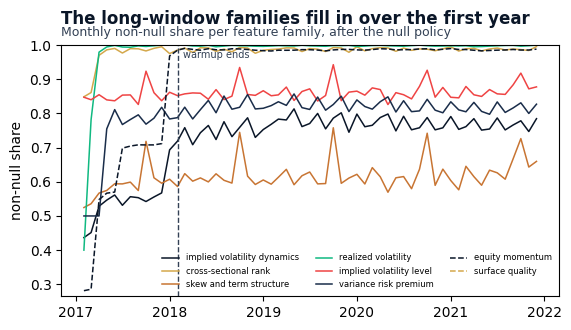

In [16]:
plot_coverage_through_time(
    coverage,
    warmup_boundary=WARMUP_END,
    title="The long-window families fill in over the first year",
    subtitle="Monthly non-null share per feature family, after the null policy",
    alt=(
        "Line chart of non-null share by feature family by month, on an axis running from "
        "about 0.28 to one. Equity momentum starts lowest at roughly 0.28 and climbs through "
        "2017, reaching one at the marked warmup boundary at the start of 2018. Realized "
        "volatility climbs from about 0.4 to one within the first two months and stays there "
        "with surface quality. The implied volatility level and the cross-sectional ranks run "
        "high throughout, the level between about 0.8 and 0.92 and the ranks close to one after "
        "the boundary. The dynamics and the variance premium settle around 0.75 to 0.82, and "
        "the skew and term structure family is the lowest and the most ragged throughout, "
        "swinging between roughly 0.57 and 0.78."
    ),
)

### F4. The timing contract

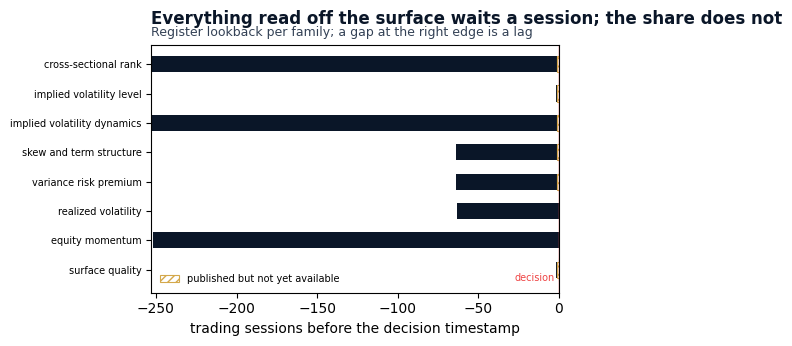

In [17]:
plot_timing_contract(
    FAMILIES,
    bar_unit="trading sessions",
    title="Everything read off the surface waits a session; the share does not",
    subtitle="Register lookback per family; a gap at the right edge is a lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision "
        "line by that family's lookback: 252 sessions for the cross-sectional ranks, the "
        "implied volatility dynamics and equity momentum, 63 for skew and term structure, the "
        "variance premium and realized volatility, and one for the implied volatility level "
        "and the surface quality family. Every option-derived bar stops one session short of "
        "the decision line and the gap is hatched; the two share-derived families, realized "
        "volatility and equity momentum, run flush to it."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives
on, whether the cross-section disagrees enough to rank on, how much of the set is one ordering
under several names, and how long a value lasts. Whether any of it predicts is
`05_evaluation`'s question, and it is asked there fold by fold rather than here on the whole
sample.

### F2. Feature distributions

The carrier family is shown on the scale a reader would judge it: the level, its session-over-
session change, its two z-scores, where it stands in its own trailing range, and its percentile
across names. The same quantity looks completely different in level, in z-score and in
percentile form, which is the point of carrying all three.

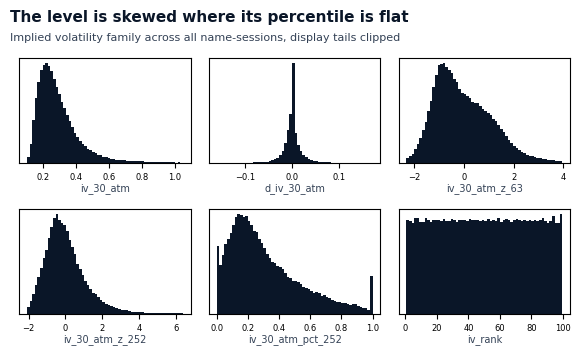

In [18]:
plot_feature_distributions(
    features,
    [
        "iv_30_atm",
        "d_iv_30_atm",
        f"iv_30_atm_z_{W['iv_zscore'][0]}",
        f"iv_30_atm_z_{W['iv_zscore'][1]}",
        f"iv_30_atm_pct_{W['iv_percentile']}",
        "iv_rank",
    ],
    title="The level is skewed where its percentile is flat",
    subtitle="Implied volatility family across all name-sessions, display tails clipped",
    alt=(
        "Six histograms in two rows. The level is a right-skewed hump peaking near 0.25 with a "
        "long upper tail. Its session-over-session change is a narrow spike at zero. The two "
        "z-scores are broad and themselves right-skewed, the 63-session one spanning about "
        "minus two to four and the 252-session one reaching six. The trailing percentile is "
        "right-skewed across its zero-to-one range with a spike at each end, and the "
        "cross-sectional percentile is close to uniform across zero to a hundred."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a date where the band
narrows to nothing there is nothing to rank, whatever the average level of implied volatility.
The band is taken across names within each session and only then averaged over the month:
pooling a month of name-sessions instead would add the movement of the market's own level from
session to session to the spread across names on a session, and a ranking model is scored on
the second alone.

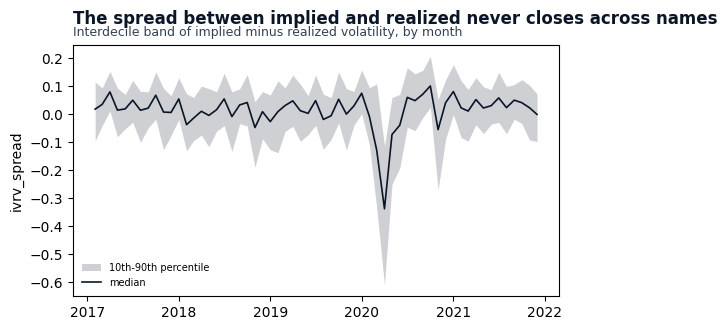

In [19]:
plot_cross_sectional_dispersion(
    features,
    "ivrv_spread",
    every="1mo",
    title="The spread between implied and realized never closes across names",
    subtitle="Interdecile band of implied minus realized volatility, by month",
    alt=(
        "Shaded band of the 10th to 90th percentile of implied minus realized volatility by "
        "month, with the median drawn through it. The median sits a little above zero for most "
        "of the sample. The band is roughly ten volatility points wide in calm periods, never "
        "narrows to nothing, and opens sharply below zero in the first half of 2020 before "
        "widening again above zero through the second half."
    ),
)

### F5. Redundancy structure

Clustering on the distance $1 - |\rho|$ groups features that carry the same ordering, whatever
the sign. Above the cut two features are close enough that a linear model cannot separate their
contributions. This states the clusters; choosing one representative from each needs a
fold-aware criterion and belongs to `05_evaluation`.

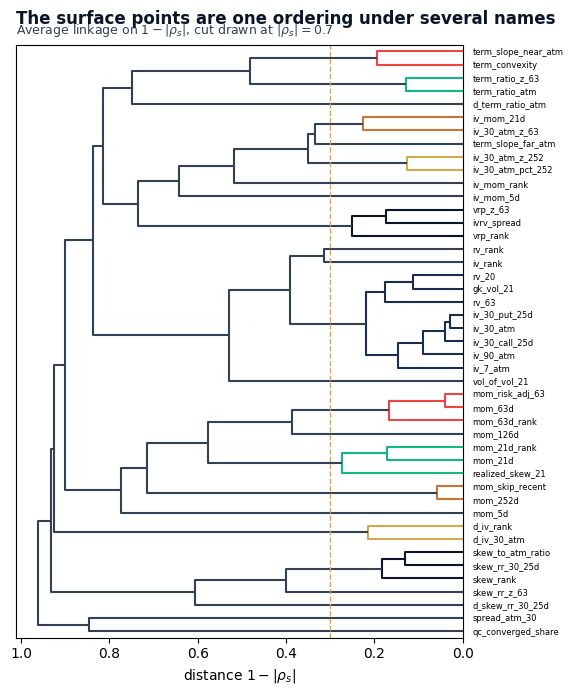

In [20]:
CUT = 0.7
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=CUT,
    title="The surface points are one ordering under several names",
    subtitle=r"Average linkage on $1 - |\rho_s|$, cut drawn at $|\rho_s| = 0.7$",
    alt=(
        "Dendrogram of every feature in the matrix. The five implied volatility level columns "
        "join each other at very small distances, and the three realized volatility estimators "
        "and their rank join the same block. The 252-session z-score joins the trailing "
        "percentile, the momentum horizons join their own ranks, the variance premium joins "
        "its rank, and the skew and term structure columns form a looser group of their own. "
        "The two surface quality columns attach only near the root, sharing an ordering with "
        "nothing else in the matrix."
    ),
)

### F6. Persistence and rank stability

The right-hand panel compares the ordering across consecutive **rebalances**, which
`config/setup.yaml` declares as a Friday close. The autocorrelation on the left is of the
feature, not of the return, and it runs to four decision cycles. A feature whose value has
decayed before the next rebalance cannot support that cadence, however well it predicts on the
day it is computed. It is estimated per name on pairs of dates exactly one lag apart and
summarized by the median over names, with a bootstrap interval over names: a correlation pooled
over every name-date pair would read high whenever names sit at different levels, whether or
not any one of them persists.

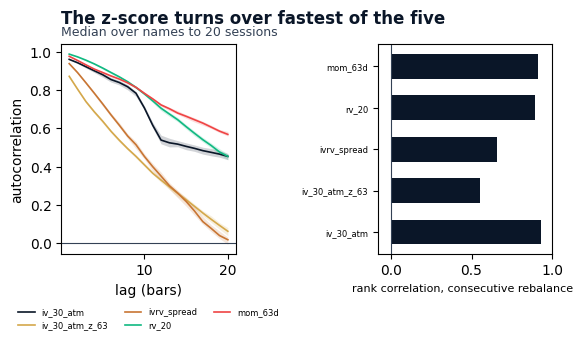

In [21]:
DECISION_CYCLE = 5
DECISION_DATES = (
    features.group_by(pl.col("timestamp").dt.truncate("1w"))
    .agg(pl.col("timestamp").max().alias("decision"))["decision"]
    .sort()
    .to_list()
)

plot_persistence(
    built,
    [
        "iv_30_atm",
        f"iv_30_atm_z_{W['iv_zscore'][0]}",
        "ivrv_spread",
        f"rv_{W['realized_vol'][0]}",
        f"mom_{W['momentum'][2]}d",
    ],
    entity=SECURITY,
    max_lag=4 * DECISION_CYCLE,
    decision_dates=DECISION_DATES,
    title="The z-score turns over fastest of the five",
    subtitle=f"Median over names to {4 * DECISION_CYCLE} sessions",
    alt=(
        "Two panels. On the left, autocorrelation against lag: the implied volatility level, "
        "the realized volatility and the medium-horizon return all start near one and decay "
        "slowly to roughly 0.45 to 0.6 over twenty sessions, while the z-score and the "
        "implied-minus-realized spread fall much faster and reach zero by the end of the axis. "
        "On the right, the cross-sectional rank correlation between consecutive weekly "
        "rebalances puts the medium-horizon return, the level and the realized volatility "
        "around 0.9, the spread at roughly 0.64, and the z-score lowest at roughly 0.56."
    ),
)

Cutting the redundancy tree at $|\rho_s| = 0.7$ leaves **24 clusters** across the **45**
columns, so nearly half the matrix repeats an ordering another column already carries.

In [22]:
print(f"{len(set(clusters.values()))} clusters over {len(feature_cols)} features at cut {CUT}")

24 clusters over 45 features at cut 0.7


## G. Emit

The parquet is written with a sidecar recording the digest of its values, its row count and key
columns, and the digest of what it was built from. This stage reads no upstream case-study
artifact, so the sidecar records the two loaded panels, each restricted to the columns and
window actually consumed, which is what answers "which data vintage produced these values". The
digest is computed over content rather than file bytes, so row order and parquet metadata leave
it alone and any feature value moves it.

In [23]:
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=PANEL_KEY,
    written_by=f"case_studies/{CASE_STUDY_ID}/03_financial_features.py",
    inputs={
        "load_sp500_daily_bars": value_digest(
            daily.select([*PANEL_KEY, SECURITY, "open", "high", "low", "close", "adj_factor"])
        ),
        "load_sp500_options_surface": value_digest(surface_raw.select([*PANEL_KEY, *SURFACE_COLS])),
    },
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}, digest {record['digest']}")
print(f"Read by 04_model_based_features.py and 05_evaluation.py, on {PANEL_KEY}")

Wrote case_studies/sp500_equity_option_analytics/features/financial.parquet, digest 95c78f053eccf7d8
Read by 04_model_based_features.py and 05_evaluation.py, on ['symbol', 'timestamp']


## Key takeaways

- **State the timing contract before writing the feature.** The register fixes each family's
  lookback and lag in the configuration, and the warmup assertion, the timing figure and the
  review a reader can run all read those numbers rather than re-deriving them from the code.
- **Lag a late-published input, and say which frame the lag is counted in.** A shift over a
  panel's own rows is a shift of one *quoted* row, which is one session only where the panel is
  dense. Saying so is the difference between a stated tolerance and a silent assumption.
- **Rank inside the frame a decision is taken over.** A percentile within the decision date is
  the ordering a long-short book acts on; a rank pooled across dates answers a different
  question with the same arithmetic.
- **Test the seal by construction, not by inspection.** Rebuilding the matrix from inputs that
  stop at the boundary and comparing values catches any transform that fits across the sample,
  including the ones nobody thought to flag.
- **Read the matrix before modelling it.** Distribution, dispersion, redundancy and decay each
  rule out a use: a feature with no cross-sectional spread cannot rank, and one whose ordering
  decays inside the rebalance cycle cannot be traded at that cadence.

### Known limitations

- The forward fill carries a stale level for up to the declared number of sessions, so a name
  quoted thinly can present a level several sessions old as the current one. It errs toward older
  information, never newer, and the surface quality family is what a downstream stage would screen
  on.
- The realized-volatility estimators are computed on close-to-close returns and on the daily
  range. Neither sees the overnight gap separately, so a name that moves between sessions and
  sits still inside them reads as calmer than it traded.
- The cross-sectional percentiles are taken over every name quoted on a date rather than over a
  liquidity-screened subset, so a thinly quoted name occupies a rank position it may not be
  tradable at. The screen is applied downstream, where `setup.yaml` declares it.

**Next**: `04_model_based_features.py` adds the features that are themselves model outputs,
where the rule is estimated from the data rather than written in advance.